In [18]:
import pandas as pd 
import numpy as np

In [19]:
df=pd.read_csv('/Users/siddharthkushwaha/Desktop/ML/Machine_learning_project/placement (2).csv')

In [20]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [22]:
df=df.iloc[:,1:]

In [23]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# Steps-- 

 0. Preprocess + EDA + Feature Selection
 1. Extract input and output cols
 2. Scale the values
 3. Train test split
 4. Train the model
 5. Evaluate the model/model selection
 6. Deploy the model

In [24]:
import matplotlib.pyplot as plt

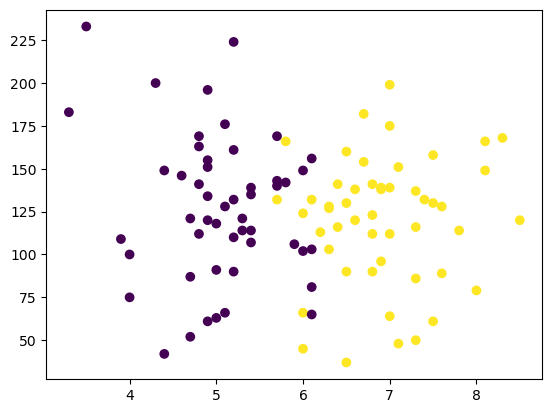

In [25]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [26]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [27]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y.shape

(100,)

In [33]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [37]:
x


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [35]:
x_train

,cgpa,iq
69,8.5,120.0
93,6.8,112.0
56,6.1,65.0
27,6.0,124.0
52,7.0,175.0
...,...,...
71,6.1,132.0
91,7.5,158.0
40,4.9,134.0
2,5.3,121.0


In [36]:
y_train

69    1
93    1
56    0
27    1
52    1
     ..
71    1
91    1
40    0
2     0
11    1
Name: placement, Length: 90, dtype: int64

In [38]:
from sklearn.preprocessing import StandardScaler


In [39]:
scaler=StandardScaler()

In [40]:
x_train=scaler.fit_transform(x_train)

In [41]:
x_train

array([[ 2.24172471, -0.11284891],
       [ 0.76079258, -0.30863497],
       [ 0.150997  , -1.45887806],
       [ 0.06388335, -0.01495588],
       [ 0.93501989,  1.23318024],
       [-1.32993513,  0.59687555],
       [ 0.06388335, -0.55336754],
       [ 1.02213355,  0.64582207],
       [-0.63302589, -0.35758148],
       [ 0.32522431, -0.52889428],
       [-0.89436685,  0.64582207],
       [-0.02323031, -0.45547451],
       [ 0.23811066, -0.28416171],
       [ 0.32522431,  0.05846389],
       [-0.98148051,  0.93950115],
       [-0.11034396,  0.42556275],
       [ 0.49945162, -0.84704663],
       [ 0.67367893,  1.40449304],
       [ 0.150997  , -0.52889428],
       [-1.06859416, -0.9204664 ],
       [-1.67838975, -1.21414548],
       [-0.89436685,  1.74711864],
       [-0.98148051,  0.40108949],
       [-0.19745762,  1.0863407 ],
       [ 0.06388335, -1.9483432 ],
       [-1.41704878,  1.84501167],
       [-2.28818533,  1.4289663 ],
       [-0.45879858, -0.43100125],
       [ 1.89327009,

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
clf=LogisticRegression()

In [44]:
# model Traning 

clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
y_pred=clf.predict(x_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [48]:
from sklearn.metrics import accuracy_score

In [49]:
accuracy_score(y_test,y_pred)

0.6

In [55]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

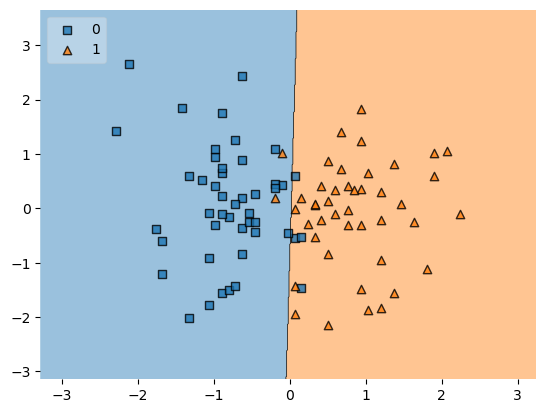

In [54]:
plot_decision_regions(X=x_train,y=y_train.values, clf=clf,legend=2)

In [56]:
import pickle

In [58]:
pickle.dump(clf,open('model.pkl','wb'))